# Marketing Funnel & Conversion Performance Analysis

## Task 3 | Future Interns - Data Science & Analytics Internship (2026)

### Project Overview
This project focuses on Marketing Funnel & Conversion Analysis, investigating the effectiveness of direct marketing campaigns within the banking sector. The goal is to analyze how potential clients move from initial contact (outbound calls) to a successful conversion (subscription to a term deposit). By identifying drop-off points and high-converting segments, this analysis provides data-driven strategies to optimize telemarketing efforts and improve overall campaign ROI.

### Dataset Description: Bank Marketing Campaign
The analysis is conducted using the Bank Marketing Campaign Dataset from the UCI Machine Learning Repository. This dataset contains information from a Portuguese banking institution's direct marketing campaigns (phone calls). It tracks the progression of clients through the sales funnel and records whether they eventually subscribed to a financial product.

**Key Data Attributes:**
* **Client Profile**: Includes age, job, marital status, and education level, which act as demographic filters for lead quality analysis.
* **Economic Indicators**: Contains macro-economic context such as employment variation rate and consumer price index at the time of the campaign.
* **Communication Details**: Tracks the contact method, day of the week, and duration of the call—a key proxy for customer engagement and "interest" in the funnel.
* **Campaign History**: Records how many times a client was contacted during this campaign and the outcome of previous marketing interactions (`poutcome`).
* **Conversion Target (`y`)**: The final funnel outcome, indicating whether the client subscribed to a term deposit (Success vs. Failure).

### Objectives & Methodology
The analytical workflow for this project involves:
* **Data Preparation**: Handling missing/unknown values, encoding categorical demographic data, and segmenting the "duration" of calls into engagement tiers.
* **Funnel Visualization**: Mapping the journey from Total Contacts → Engaged Leads (duration threshold) → Successful Conversions (subscriptions).
* **Conversion Rate Analysis**: Calculating the "Call-to-Subscription" ratio and identifying which demographic segments have the highest conversion velocity.
* **Feature Impact Analysis**: Evaluating how external factors (like duration or previous outcomes) correlate with a user moving to the final "Customer" stage.
* **Insight Generation**: Identifying "leaks" where high volumes of calls result in zero engagement and determining the optimal number of contacts per lead.
* **Actionable Recommendations**: Providing guidance on lead scoring and timing strategies to improve conversion rates for future campaigns.

### Research Questions
To guide the analysis, this project seeks to answer:
* **Funnel Efficiency**: What is the overall conversion rate from total calls made to successful term deposit subscriptions?
* **Engagement Drivers**: Is there a specific "engagement duration" (call length) that serves as a reliable predictor of a lead converting into a customer?
* **Lead Quality by Profession**: Which job categories or demographic segments show the highest propensity to convert, and should they be prioritized in the funnel?
* **Timing & Frequency**: Does the number of contacts during a campaign increase the likelihood of conversion, or is there a "diminishing returns" point where users drop out?
* **Optimization Priority**: Based on past campaign outcomes, which segment of "previously contacted" clients represents the most efficient path to conversion for new products?

## DATA PREPROCESSING

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('bank-full.csv', sep=';')

In [4]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
data.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


This dataset contains client demographic profiles, financial indicators, and historical marketing contact details used to track and predict successful subscriptions to a bank term deposit.

In [6]:
data.shape

(45211, 17)

The dataset contains 17 attributes and 45 211 row entries.

In [7]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


The summary statistics reveal that the average client is approximately 41 years old with a balance of €1,362, while the typical marketing call lasts about 4 minutes (258 seconds). Furthermore, the data shows significant variability in customer engagement, with call durations ranging from a few seconds to over 80 minutes and balances spanning from negative values to over €100,000.

## DATA CLEANING

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


There are several crucial data type changes to make to ensure the analysis is both memory-efficient and mathematically sound.

In [9]:
# 1. Convert y to binary
data['y_numeric'] = data['y'].map({'yes': 1, 'no': 0})

# 2. Convert text columns to Category
cat_columns = ['job', 'marital', 'education', 'contact', 'poutcome']
for col in cat_columns:
    data[col] = data[col].astype('category')

# 3. Order the months chronologically
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
data['month'] = pd.Categorical(data['month'], categories=month_order, ordered=True)

In [10]:
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
y_numeric    0
dtype: int64

There are no missing values in the data so we go on to check for duplicates

In [11]:
data.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset so we check for outliers

In [12]:
kurtosis_values = data.select_dtypes(include=['number']).kurt()

print("Kurtosis values:")
print(kurtosis_values)

Kurtosis values:
age             0.319570
balance       140.751547
day            -1.059897
duration       18.153915
campaign       39.249651
pdays           6.935195
previous     4506.860660
y_numeric       3.681142
dtype: float64


The extremely high kurtosis values in variables like balance, duration, and previous indicate "heavy-tailed" distributions with a significant presence of extreme outliers. This suggests that while most customers follow a standard pattern, there are small, highly influential groups of "super-leads" (those with massive balances or extremely long engagement times) that deviate sharply from the norm.

In [13]:
high_kurtosis_cols = ['balance', 'duration', 'campaign', 'pdays', 'previous']

outlier_summary = []
for col in high_kurtosis_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data[col] < lower) | (data[col] > upper)).sum()
    pct   = round(n_out / len(data) * 100, 2)
    outlier_summary.append({
        'Column': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': n_out, 'Outlier %': pct
    })

pd.DataFrame(outlier_summary)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729,10.46
1,duration,103.0,319.0,216.0,-221.0,643.0,3235,7.16
2,campaign,1.0,3.0,2.0,-2.0,6.0,3064,6.78
3,pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257,18.26
4,previous,0.0,0.0,0.0,0.0,0.0,8257,18.26


While the IQR analysis flags extreme values across all five high-kurtosis columns, these data points represent real financial states and genuine customer behaviors rather than measurement errors. Consequently, all outliers will be retained to preserve their strong predictive signals, with potential capping or transformations deferred to the feature engineering stage.

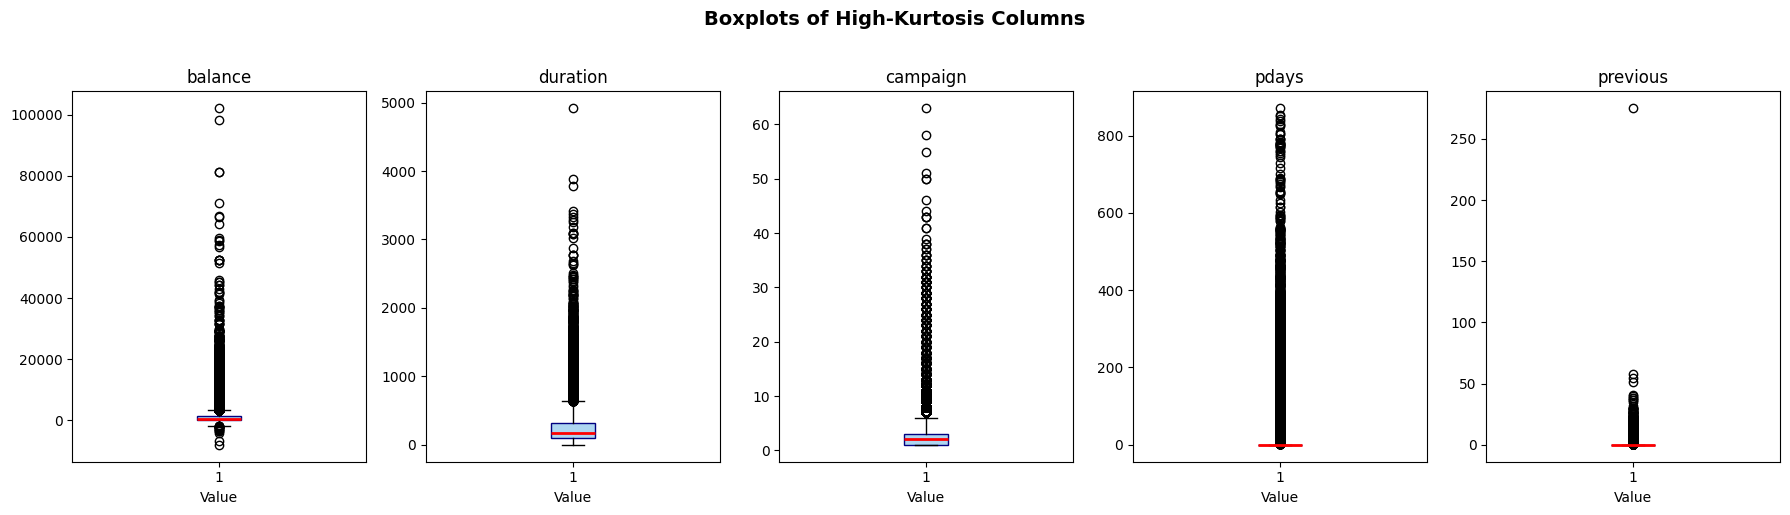

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, high_kurtosis_cols):
    ax.boxplot(data[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('Value', fontsize=10)
plt.suptitle('Boxplots of High-Kurtosis Columns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The boxplots reveal a strong right skew, with the majority of clients clustering at low values while a small number of extreme cases create a long tail. These outliers represent genuine customer behaviors (rather than noise) offering critical edge-case data for the model to learn from.

In [15]:
# This dataset uses 'unknown' instead of NaN for missing categoricals.

unknown_summary = {}
for col in data.columns:
    try:
        count = (data[col].astype(str).str.lower() == 'unknown').sum()
        if count > 0:
            unknown_summary[col] = {
                'Count': count,
                'Percentage (%)': round(count / len(data) * 100, 2)
            }
    except Exception:
        pass

unknown_df = pd.DataFrame(unknown_summary).T.sort_values('Percentage (%)', ascending=False)
print("Columns with 'unknown' values:")
display(unknown_df)

Columns with 'unknown' values:


,Count,Percentage (%)
poutcome,36959.0,81.75
contact,13020.0,28.80
education,1857.0,4.11
job,288.0,0.64


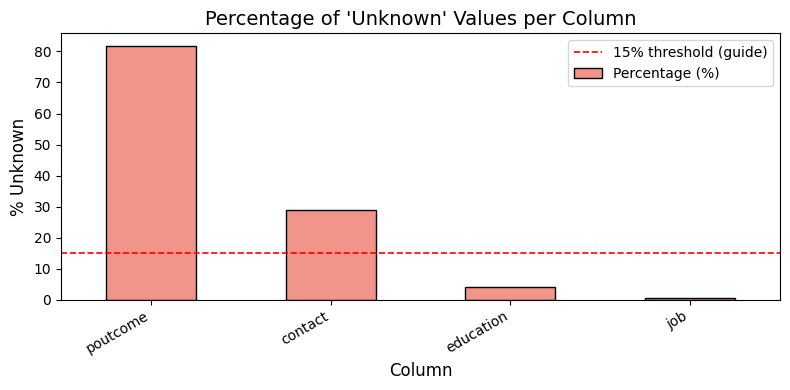

In [16]:
ax = unknown_df['Percentage (%)'].plot(kind='bar', figsize=(8, 4),
                                        color='#F1948A', edgecolor='black')
ax.set_title("Percentage of 'Unknown' Values per Column", fontsize=14)
ax.set_ylabel("% Unknown", fontsize=12)
ax.set_xlabel("Column", fontsize=12)
ax.axhline(y=15, color='red', linestyle='--', linewidth=1.2, label='15% threshold (guide)')
ax.legend(fontsize=10)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

- 'contact' and 'poutcome' both sit well above the 15% threshold, so imputing them would be misleading — we keep 'unknown' as a valid category. 
- 'job' and 'education' are safely below the threshold, so we replace their unknowns with the mode. 
- 'default' has negligible unknowns and is handled the same way. This approach preserves the integrity of the data while eliminating noise in the lower-volume columns.

In [17]:
for col in ['job', 'education']:
    mode_val = data[col].astype(str).replace('unknown', pd.NA).mode()[0]
    data[col] = data[col].astype(str).replace('unknown', mode_val).astype('category')
    print(f"'{col}' unknowns replaced with mode: '{mode_val}'")

data['default'] = data['default'].astype(str)
if 'unknown' in data['default'].values:
    data['default'] = data['default'].replace('unknown', data['default'].mode()[0])

remaining = {col: (data[col].astype(str).str.lower() == 'unknown').sum()
             for col in ['job', 'education', 'default']}
print("\nRemaining unknown counts after imputation:", remaining)

'job' unknowns replaced with mode: 'blue-collar'
'education' unknowns replaced with mode: 'secondary'

Remaining unknown counts after imputation: {'job': np.int64(0), 'education': np.int64(0), 'default': np.int64(0)}


In [18]:
# fix naming conventions

print("Column names:", data.columns.tolist())

# Standardise all string/category values: strip whitespace, lowercase
for col in data.select_dtypes(include=['object', 'category']).columns:
    data[col] = data[col].astype(str).str.strip().str.lower().astype('category')

print("\ny value counts:\n", data['y'].value_counts())
print("\nSample cleaned values - job:", data['job'].unique()[:5].tolist())

Column names: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'y_numeric']


C:\Users\raees\AppData\Local\Temp\ipykernel_11936\796816493.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include=['object', 'category']).columns:



y value counts:
 y
no     39922
yes     5289
Name: count, dtype: int64

Sample cleaned values - job: ['management', 'technician', 'entrepreneur', 'blue-collar', 'retired']


Standardizing text through whitespace stripping and lowercase conversion prevents redundant categories caused by inconsistent formatting. This ensures data integrity, allowing models and operations to treat identical categories as a single, consistent group.

In [19]:
# Final cleaning checkpoint 

print(f"Shape         : {data.shape}")
print(f"Missing (NaN) : {data.isnull().sum().sum()}")
print(f"Duplicates    : {data.duplicated().sum()}")
print("\nData types:")
print(data.dtypes)

Shape         : (45211, 18)
Missing (NaN) : 0
Duplicates    : 0

Data types:
age             int64
job          category
marital      category
education    category
default      category
balance         int64
housing      category
loan         category
contact      category
day             int64
month        category
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome     category
y            category
y_numeric       int64
dtype: object


In [20]:
# save final cleaned data 

data.to_csv('bank-full-cleaned.csv', index=False)

## DATA ANALYSIS AND EXPLORATION